In [33]:
import pandas as pd
import numpy as np

###`Q-1:` Write a program to create an empty series.

In [ ]:
# code here
print(pd.Series())

Series([], dtype: object)


###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [ ]:
# code here
s1 = pd.Series([1,2,3,4,5])
s2 = pd.Series([6,7,8,9,10])

print(s1 + s2)
print(s2 - s1)
print(s1 * s2)
print(s1/s2)

0     7
1     9
2    11
3    13
4    15
dtype: int64
0    5
1    5
2    5
3    5
4    5
dtype: int64
0     6
1    14
2    24
3    36
4    50
dtype: int64
0    0.166667
1    0.285714
2    0.375000
3    0.444444
4    0.500000
dtype: float64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [ ]:
# code here
s1 = pd.Series([2, 4, 6, 8, 10])
s2 = pd.Series([1, 3, 5, 7, 10])

print(s1 > s2)
print(s1 < s2)
print(s1 == s2)
print(s1 != s2)
print(s1 >=s2)
print(s1 <= s2)

0     True
1     True
2     True
3     True
4    False
dtype: bool
0    False
1    False
2    False
3    False
4    False
dtype: bool
0    False
1    False
2    False
3    False
4     True
dtype: bool
0     True
1     True
2     True
3     True
4    False
dtype: bool
0    True
1    True
2    True
3    True
4    True
dtype: bool
0    False
1    False
2    False
3    False
4     True
dtype: bool


###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [ ]:
# code here
def change_dtype(series, dtype):
  if dtype == 'float':
    return pd.to_numeric(series, errors='coerce')
  elif dtype == 'int':
    return pd.to_numeric(series, errors='coerce').dropna().astype('int')
  else:
    return series.astype(dtype)

# Example usage
series = pd.Series([1, 2, 'Python', 2.0, True, 100])
converted_series = change_dtype(series, 'float')
print(converted_series)

0      1.0
1      2.0
2      NaN
3      2.0
4      1.0
5    100.0
dtype: float64


Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

###`Q-6` Find top 10 most run getter from the series.

In [46]:
# code here
runs = pd.read_csv('/content/batsman_runs_series.csv',index_col = 'batter').squeeze(True)
runs.sort_values(ascending = False).head(10)

,batsman_run
batter,
V Kohli,6634
S Dhawan,6244
DA Warner,5883
RG Sharma,5881
SK Raina,5536
AB de Villiers,5181
CH Gayle,4997
MS Dhoni,4978
RV Uthappa,4954


###`Q-7` No of players having runs above 3000

In [49]:
# code here
print((runs > 3000).sum())

20


###`Q-8` No of players having runs above mean value?

In [52]:
# code here
print((runs > runs.mean()).sum())

128


Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



###`Q-9`
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [64]:
# code here (i and ii)
items = pd.read_csv('/content/items.csv',index_col = 'item_name').squeeze(True)
print('No of nan values: ',items.isnull().sum())


No of nan values:  50


In [65]:
items.info()

<class 'pandas.core.series.Series'>
Index: 4622 entries, Chips and Fresh Tomato Salsa to Chicken Salad Bowl
Series name: item_price
Non-Null Count  Dtype 
--------------  ----- 
4572 non-null   object
dtypes: object(1)
memory usage: 72.2+ KB


In [137]:
# ii.
new_items = pd.to_numeric(items.str[1:]) * 282.88
new_items.head()

,item_price
item_name,
Chips and Fresh Tomato Salsa,676.0832
Izze,958.9632
Nantucket Nectar,958.9632
Chips and Tomatillo-Green Chili Salsa,676.0832
Chicken Bowl,4803.3024


In [138]:
# second method as per given question more efficient
# iii
new_items = items.str[1:].astype('float') * 282.88
new_items.head()

,item_price
item_name,
Chips and Fresh Tomato Salsa,676.0832
Izze,958.9632
Nantucket Nectar,958.9632
Chips and Tomatillo-Green Chili Salsa,676.0832
Chicken Bowl,4803.3024


In [139]:
# iv
new_items.fillna(new_items.mean(),inplace=True)

In [140]:
new_items.isnull().sum()

np.int64(0)

###`Q-10`:
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



In [141]:
# code here
# i
print(new_items.mean())

2111.1423496062994


In [142]:
# ii
print("30th Percentile:",np.percentile(new_items.values,30))
print("6th Percentile:", np.percentile(new_items.values,6))

30th Percentile: 1258.816
6th Percentile: 353.6


<Axes: title={'center': 'Price Distribution in PKR'}, ylabel='Frequency'>

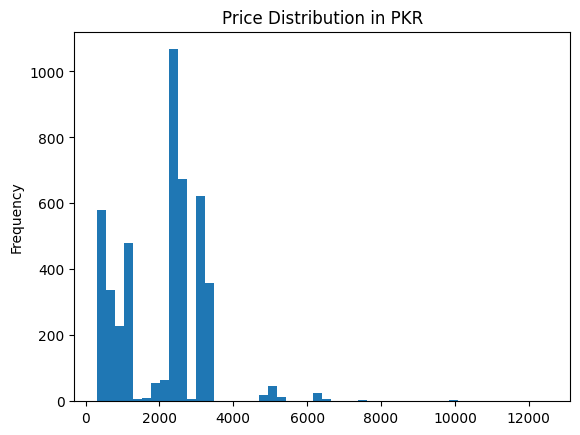

In [150]:
# iii
new_items.plot(kind = 'hist', bins = 50, title='Price Distribution in PKR')

In [146]:
# iv
print(new_items.between(1000, 2000).sum())

553
